# Posterior Predictive Checks

Posterior predictive checks (PPCs) are a principled Bayesian model criticism technique used to evaluate whether a fitted model can adequately reproduce key structure in the observed data. After estimating the posterior distribution we generate replicated datasets from the posterior predictive distribution. By comparing CAFs, CDFs and delta-functions on the observed data to those computed on simulated replications, we assess model adequacy at the level of generative behavior rather than parameter fit alone. 


In [1]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import bayesflow as bf
import keras

from dmc import dmc_helpers, DMC


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## Load Approximator

In order to sample from the posterior, we have to load the pretrained network:

In [2]:
approximator = keras.saving.load_model('../training_checkpoints/updated_priors_sdr_estimated.keras')

/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


We load our empirical data:

In [3]:
data = pd.read_csv('../empirical_data/experiment_data_narrow.csv')

data = (data[['participant', 'rt', 'accuracy', 'congruency_num']]
        .rename(columns={'congruency_num': "congruency"})
)

data

,participant,rt,accuracy,congruency
0,6361,0.4690,1,0
1,5281,0.4540,1,0
2,8785,0.4345,1,0
3,6253,0.2900,1,1
4,6427,0.5150,1,0
...,...,...,...,...
24842,1601,0.5150,1,1
24843,1813,0.4891,1,1
24844,8311,0.4300,1,0
24845,161753,0.4920,1,1


Now we can sample from the Posterior:

In [4]:
post_samples = dmc_helpers.fit_empirical_data(data, approximator=approximator, id_name='participant', rt='rt', accuracy='accuracy', congruency='congruency')

Sampling posteriors:   0%|          | 0/72 [00:00<?, ?it/s]

Sampling posteriors:  12%|█▎        | 9/72 [00:08<00:55,  1.13it/s]

[ID 808] UserWarning: RT Difference between incongruent - congruent conditions is negative: -0.0026553881511746646. Please check the coding of congruency conditions.


Sampling posteriors: 100%|██████████| 72/72 [01:07<00:00,  1.07it/s]


In [5]:
model_specs = {"simulation_settings": {"prior_means": np.array([20.49, 118.36, 0.57, 358.01, 61.0, 36.93]),
                                       "prior_sds": np.array([8.4, 37.6, 0.12, 24.27, 13.23, 8.6]),
                                       'sdr_fixed': None,
                                       "tmax": 1500,
                                       "contamination_probability": None,
                                       "min_num_obs": 50,
                                       "max_num_obs": 1000,
                                       "fixed_num_obs": None,
                                       'param_names': ("A", "tau", "mu_c", "mu_r", "b", "sd_r")}}


simulator = DMC(**model_specs['simulation_settings'])

# Resimulate Data

The function `resim_data` takes both empirical data (`data`) and posterior samples (`post_samples`) and iterates across all IDs in the empirical data. For each empirical ID, 100 resimulations are simulated drawing from the corresponding posterior samples.

In [6]:
ppc_data = dmc_helpers.resim_data(data, post_samples, simulator=simulator, num_resims=100,id_name='participant', rt='rt', congruency='congruency')

Resimulate 100 data sets per ID: 100%|██████████| 72/72 [01:31<00:00,  1.27s/it]


# Assess Model Fit

First, let's have a look at the aggregated empirical data. We can compute CAFs, CDFs and delta functions as:

In [7]:
caf_emp, cdf_emp, delta_emp = dmc_helpers.compute_stats(data, id_name='participant', rt='rt', congruency='congruency')

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: title={'center': 'CAF'}, xlabel='Bins', ylabel='CAF'>,
        <Axes: title={'center': 'CDF'}, xlabel='RT[s]', ylabel='Cumulative Density'>,
        <Axes: title={'center': '$\\Delta$-Function'}, xlabel='RT[s]', ylabel='$\\Delta$'>],
       dtype=object))

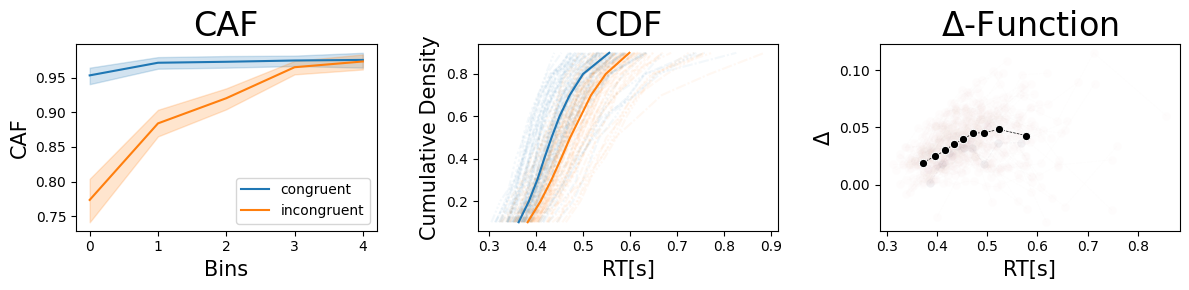

In [8]:
dmc_helpers.plot_stats(caf_emp, cdf_emp, delta_emp, id_name='participant', rt='rt', congruency='congruency')

Similarly, we can compute aggregated data for the resimulated data sets:

In [9]:
caf, cdf, delta = dmc_helpers.compute_stats(ppc_data, id_name='id', rt='rt', congruency='congruency')

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: title={'center': 'CAF'}, xlabel='Bins', ylabel='CAF'>,
        <Axes: title={'center': 'CDF'}, xlabel='RT[s]', ylabel='Cumulative Density'>,
        <Axes: title={'center': '$\\Delta$-Function'}, xlabel='RT[s]', ylabel='$\\Delta$'>],
       dtype=object))

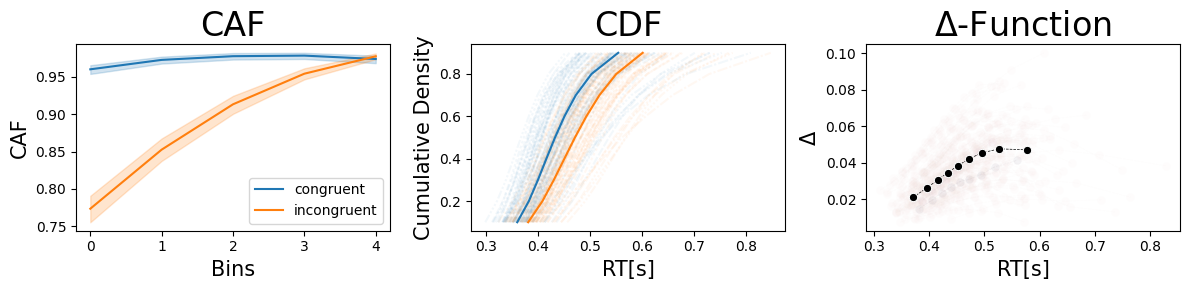

In [10]:
dmc_helpers.plot_stats(caf, cdf, delta, id_name='id', rt='rt', congruency='congruency')

The function `plot_fit` takes aggregated data sets from both, empirical data as well as resimulated data:

(<Figure size 1200x300 with 3 Axes>,
 array([<Axes: title={'center': 'CAF'}, xlabel='Bins', ylabel='CAF'>,
        <Axes: title={'center': 'CDF'}, xlabel='RT[s]', ylabel='Cumulative Density'>,
        <Axes: title={'center': '$\\Delta$-Function'}, xlabel='RT[s]', ylabel='$\\Delta$'>],
       dtype=object))

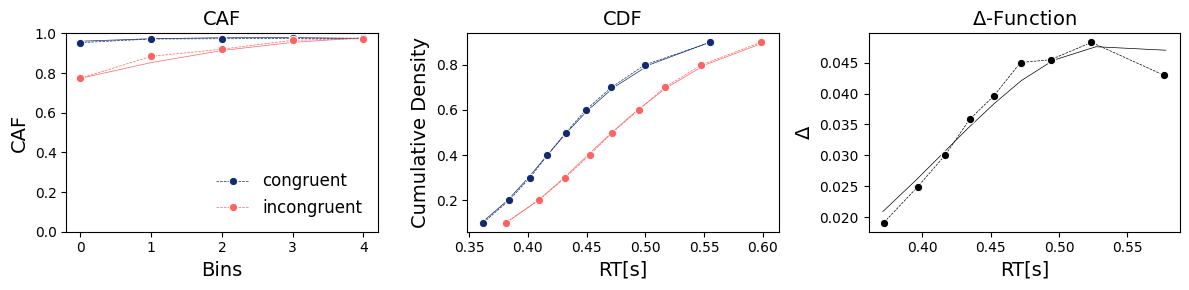

In [11]:
dmc_helpers.plot_fit(caf, cdf, delta, caf_emp, cdf_emp, delta_emp, congruency='congruency', congruency_emp='congruency')